# Profilado, limpieza y transformación
---

## Identificación y corrección de errores: Valores faltantes, duplicados, inconsistencias

* En el proceso de limpieza y transformación de datos, la identificación y corrección de errores es crucial para asegurar la calidad y confiabilidad de los datos

1. **Valores Faltantes**
* **Eliminación de filas o columnas**
* **Imputación de valores**: sustituir valores faltantes con:
    * **Media o Mediana**
    * **Moda**
    * **Métodos avanzados**
* **Creación de una categoría especial**

2. **Duplicados**
Detección de duplicados
* **Eliminación de duplicados**
* **Consolidación de duplicados parciales**

3. **Inconsistencias**
* **Normalización de formatos**
* **Corrección de errores tipográficos**
* **Establecimiento de reglas de validación**

## Transformación de datos: estandarización

### Valores Faltantes

#### Eliminación de filas o columnas

* Si el porcentaje de valores faltantes en una fila o columna es alto, puede optarse por eliminarlos, siempre que esto no afecte significativamente el análisis

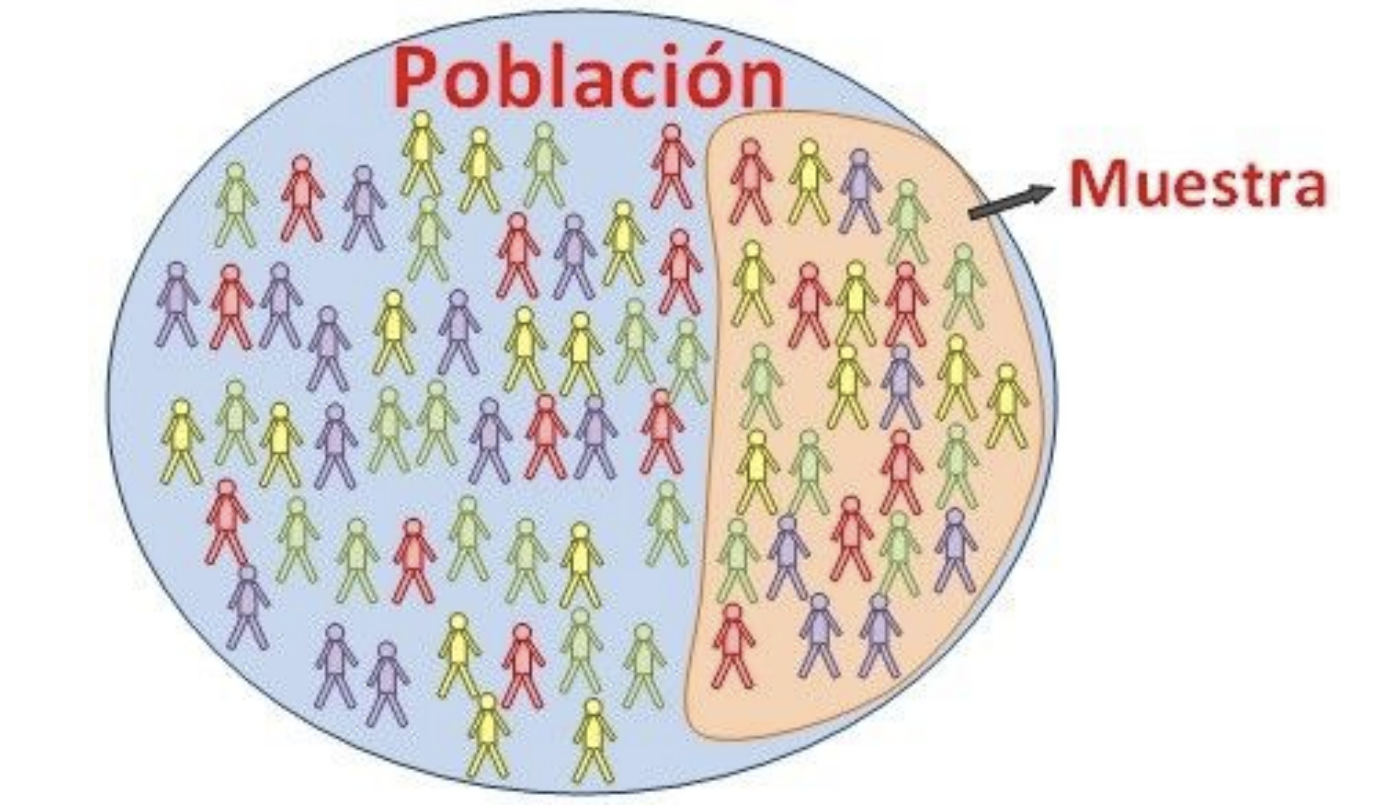

#### Imputación de valores

* Es un proceso estadístico que consiste en sustituir los valores faltantes en un conjunto de datos por otros valores estimados
* Se realiza para poder analizar los datos con técnicas estadísticas específicas
* La imputación preserva todos los casos reemplazando los datos faltantes con un valor estimado basado en otra información disponible

| ID | Nombre | Edad | Ciudad       | Ingreso Mensual |
| -- | --     | --   | --           | --              |
| 1  | Juan   | 30   | Buenos Aires | 45000           |
| 2  | María  |      | Córdoba      | 38000           |
| 3  | Pedro  | 28   |              | 50000           |
| 4  | Lucía  | 35   | Mendoza      |                 |
| 5  | Martín | 40   | Buenos Aires | 60000           |

Sustituir valores faltantes con:
* **Media o Mediana**: para datos numéricos, dependiendo de si la distribución es normal o sesgada (valor de un datos extremo)
* **Moda**: útil para datos categóricos
* **Métodos avanzados**: imputación usando modelos como KNN o regresión

**Ejemplo de datos numéricos**:

| Empleado | Ingreso Mensual |
| --       | --              |
| 1        | 2000            |
| 2        | 2200            |
| 3        | 2500            |
| 4        | 2600            |
| 5        | 2700            |
| 6        | 2800            |
| 7        | 3000            |
| **8**    | **50000**       |
| 9        | 2800            |
| **10**   |                 |

* Se observa un ingreso muy alto (50000) en comparación con el resto, lo cual podría ser un error o un valor extremo real
* También hay un valor faltante para el Empleado 10 que se quiere imputar

* **Si se usa la media (promedio)**:
    * Media = (2000 + 2200 + 2500 + 2600 + 2700 + 2800 + 3000 + 50000 + 2800) / 9 ≈ **7433.33**
    * Este valor promedio **es muy alto y no representa bien los ingresos típicos de los empleados** debido al ingreso extremo de $50,000 

* **Si se usa la mediana**:
    * Se ordenan los ingresos: 2000, 2200, 2500, 2600, 2700, 2800, 2800, 3000, 50000
    * **La mediana es el valor en el centro de la lista ordenada, que es 2700**
    * Al imputar el valor faltante con la mediana, el ingreso del Empleado 10 sería $2700, que **representa mejor los ingresos de la mayoría de los empleados**, ya que no se ve afectado por el valor extremo

**Ejemplo de datos categóricos**:

| Cliente | Preferencia de Comida |
| --      | --                    |
| 1       | Italiana              |
| 2       | Mexicana              |
| 3       | Italiana              |
| 4       | China                 |
| 5       | Italiana              |
| 6       | Mexicana              |
| 7       | Italiana              |
| 8       | China                 |
| 9       | Mexicana              |
| 10      |                       |

* Se observa la frecuencia de cada preferencia de comida:
    * Italiana: 4 veces
    * Mexicana: 3 veces
    * China: 2 veces
* En este caso, **la moda es "Italiana"**, ya que es el tipo de comida que más frecuentemente prefieren los clientes
* Al imputar el valor faltante con la moda, la preferencia de comida del Cliente 10 sería "Italiana", **asumiendo que la moda es representativa de las preferencias generales del grupo**

* **Ejemplo de dataset de una tienda en línea que incluye información sobre clientes y sus hábitos de compra**:

| Cliente | Edad | Ingreso Mensual | Género | Ciudad       |
| --      | --   | --              | --     | --           |
| 1       | 25   | 45000           | M      | Buenos Aires |
| 2       | 30   |                 | F      | Córdoba      |
| 3       | 35   | 60000           | F      | Buenos Aires |
| 4       | 29   | 50000           | M      | Mendoza      |
| 5       | 40   |                 | F      | Córdoba      |

**Imputación usando K-Nearest Neighbors (KNN)**
* Con el algoritmo KNN, calculamos la similitud entre el cliente 2 (con datos faltantes) y otros clientes, en función de variables como la edad, el género y la ciudad
* **El algoritmo selecciona los "K" clientes más cercanos** (por ejemplo, los 3 más similares) y utiliza sus valores de "Ingreso Mensual" para estimar el valor faltante para el cliente 2
* Si los ingresos de los vecinos más cercanos (Clientes 1, 3, y 4) son 45000, 60000 y 50000, el algoritmo podría imputar un valor promedio de 51666 para el cliente 2

* **Ejemplo de dataset de estudiantes**

| Estudiante | Calificación | Asistencia (%) | Horas de Estudio |
| --         | --           | --             | --               |
| 1          | 85           | 90             | 10               |
| 2          | 78           | 80             |                  |
| 3          | 92           | 95             | 15               |
| 4          | 88           | 88             | 12               |
| 5          | 75           | 70             |                  |

**Imputación usando Regresión**:
* Se utiliza **regresión lineal** para modelar la relación entre las variables "Calificación" y "Asistencia" (predictoras) y "Horas de Estudio" (objetivo)
* Se entrena un modelo de regresión lineal con los estudiantes que tienen el dato de "Horas de Estudio" completo
* Luego, se usa el modelo entrenado para predecir las horas de estudio para estudiantes con datos faltantes en esta columna (por ejemplo, estudiante 2)
* Si el modelo predice que el estudiante 2 debería estudiar alrededor de 8 horas en función de su calificación y asistencia, se puede imputar este valor

**Creación de una categoría especial**:
* Para variables categóricas, puede ser útil crear una categoría como "Desconocido" o "Sin información"

### Duplicados

* **Detección de duplicados**: identificar filas repetidas mediante herramientas o scripts que comparan registros completos o campos específicos
* **Eliminación de duplicados**: tras identificar duplicados, eliminar las filas redundantes manteniendo una sola instancia del registro
* **Consolidación de duplicados parciales**: en algunos casos, los duplicados pueden tener ligeras variaciones en ciertos campos. Aquí, la fusión o consolidación de los datos puede ser útil

### Incosistencias

* **Normalización de formatos**: asegurar que los datos tengan un formato homogéneo, por ejemplo, en fechas, capitalización de textos o unidades de medida
* **Corrección de errores tipográficos**: usar algoritmos de detección de similitudes o listas de valores válidos para corregir errores tipográficos o discrepancias en variables categóricas
* **Establecimiento de reglas de validación**: crear reglas y filtros para asegurar que los datos cumplen con ciertos criterios, como rangos de valores permitidos o relaciones entre variables

### ¿Qué tan buena debe ser la calidad de los datos?

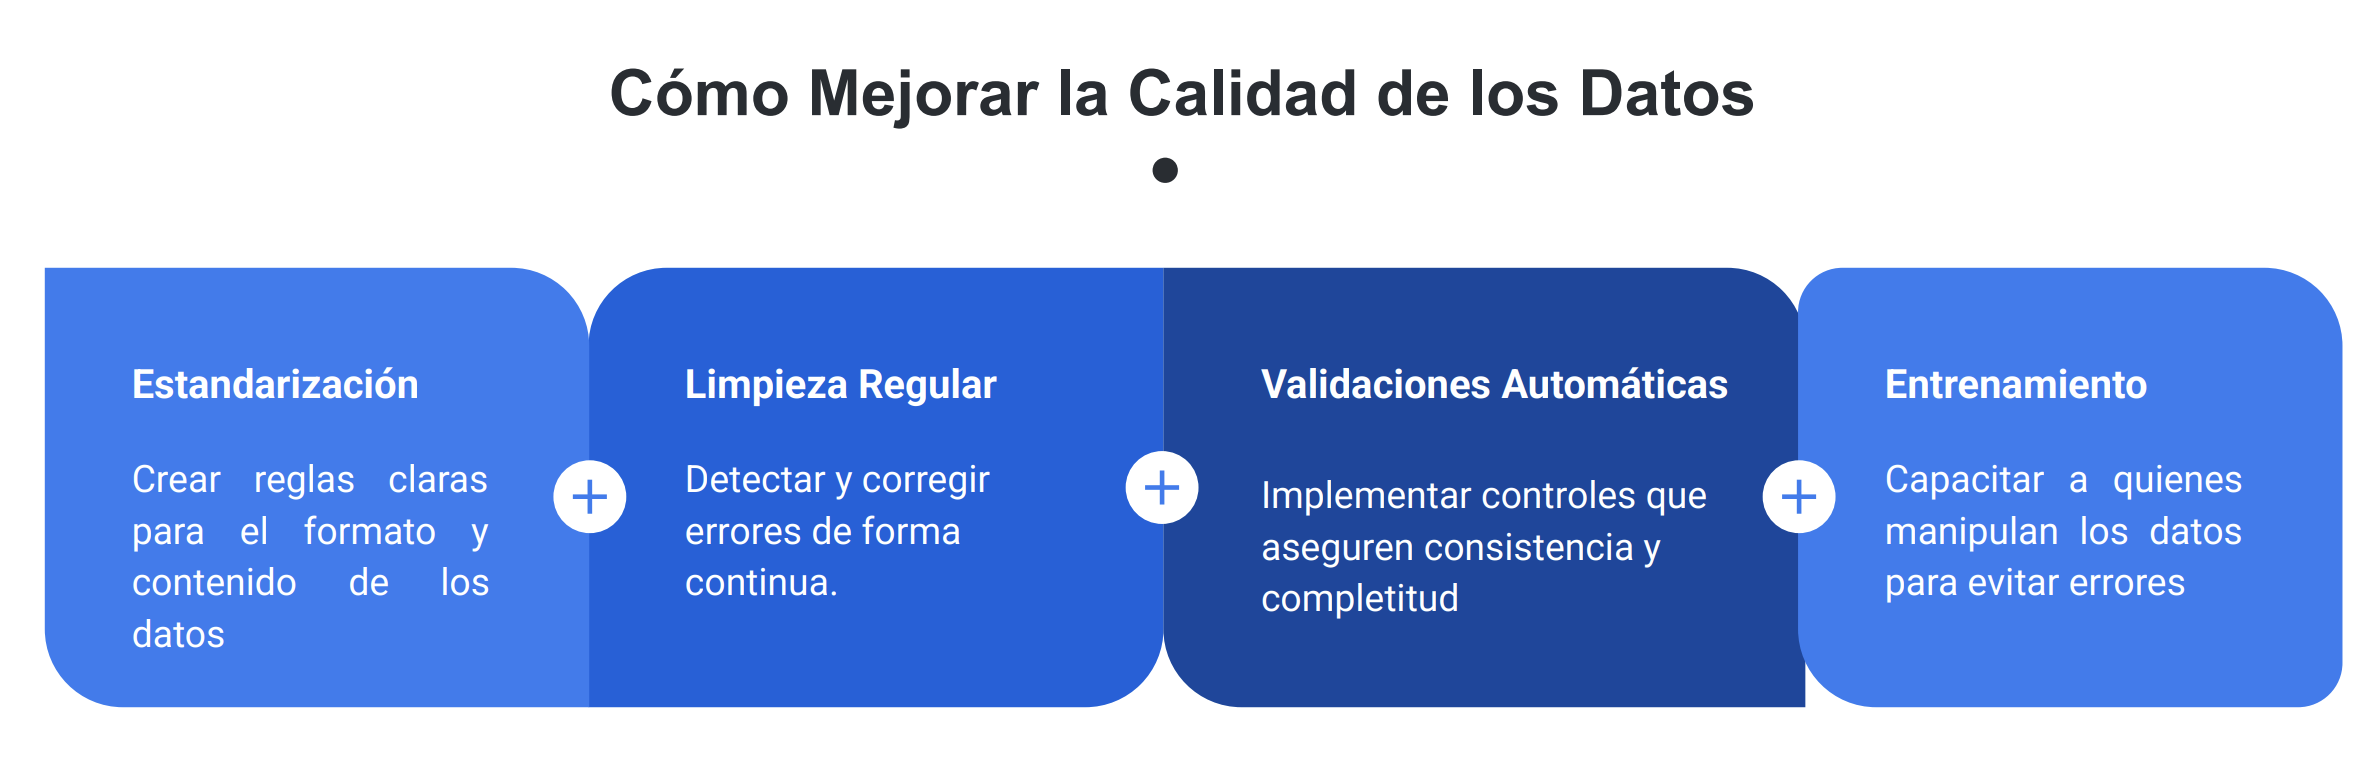

## Profilado de datos y análisis exploratorio

### Profilado de datos

* **Es el proceso de examinar, analizar y resumir conjuntos de datos para conocer su estructura, contenido y calidad**
* Su objetivo principal es detectar problemas antes de usar los datos
* Permite identificar:
    * Valores nulos o faltantes
    * Valores duplicados
    * Inconsistencias
    * Valores fuera de rango
    * Tipos de datos incorrectos
    * Relaciones entre atributos

#### Tipos de Profilado

* **a) Profilado de columna**: analiza cada atributo individualmente. Ejemplos:
    * % de valores nulos
    * Mínimo, máximo
    * Media, mediana
    * Distribución de valores
* **b) Profilado de estructura**: evalúa cómo están organizados los datos. Ejemplos:
    * Tipos de datos (numérico, texto, fecha)
    * Longitud de campos
    * Formatos (ej. fechas mal formateadas)
* **c) Profilado de relaciones**: analiza dependencias entre columnas. Ejemplos:
    * Claves primarias duplicadas
    * Integridad referencial
    * Dependencias funcionales
* **d) Profilado de contenido**: busca patrones y anomalías. Ejemplos:
    * Valores inválidos (N/A, ??)
    * Inconsistencias semánticas
    * Valores atípicos (outliers)

### EDA: Análisis Exploratorio de Datos

* Es un enfoque para comprender los datos mediante estadísticas y visualizaciones
* **Va más allá del perfilado: busca entender comportamientos y patrones**
* **Objetivos**:
    * Comprender la distribución de los datos
    * Detectar patrones ocultos
    * Identificar outliers
    * Evaluar relaciones entre variables
    * Formular hipótesis

#### Técnicas comunes de EDA

* **Estadística descriptiva**
    * Media, mediana, moda
    * Desviación estándar
    * Percentiles
* **Visualizaciones**
    * Histogramas
    * Boxplots
    * Gráficos de dispersión
* **Análisis de correlación**
    * Permite detectar relaciones entre variables
    * Ejemplo: precio vs cantidad vendida

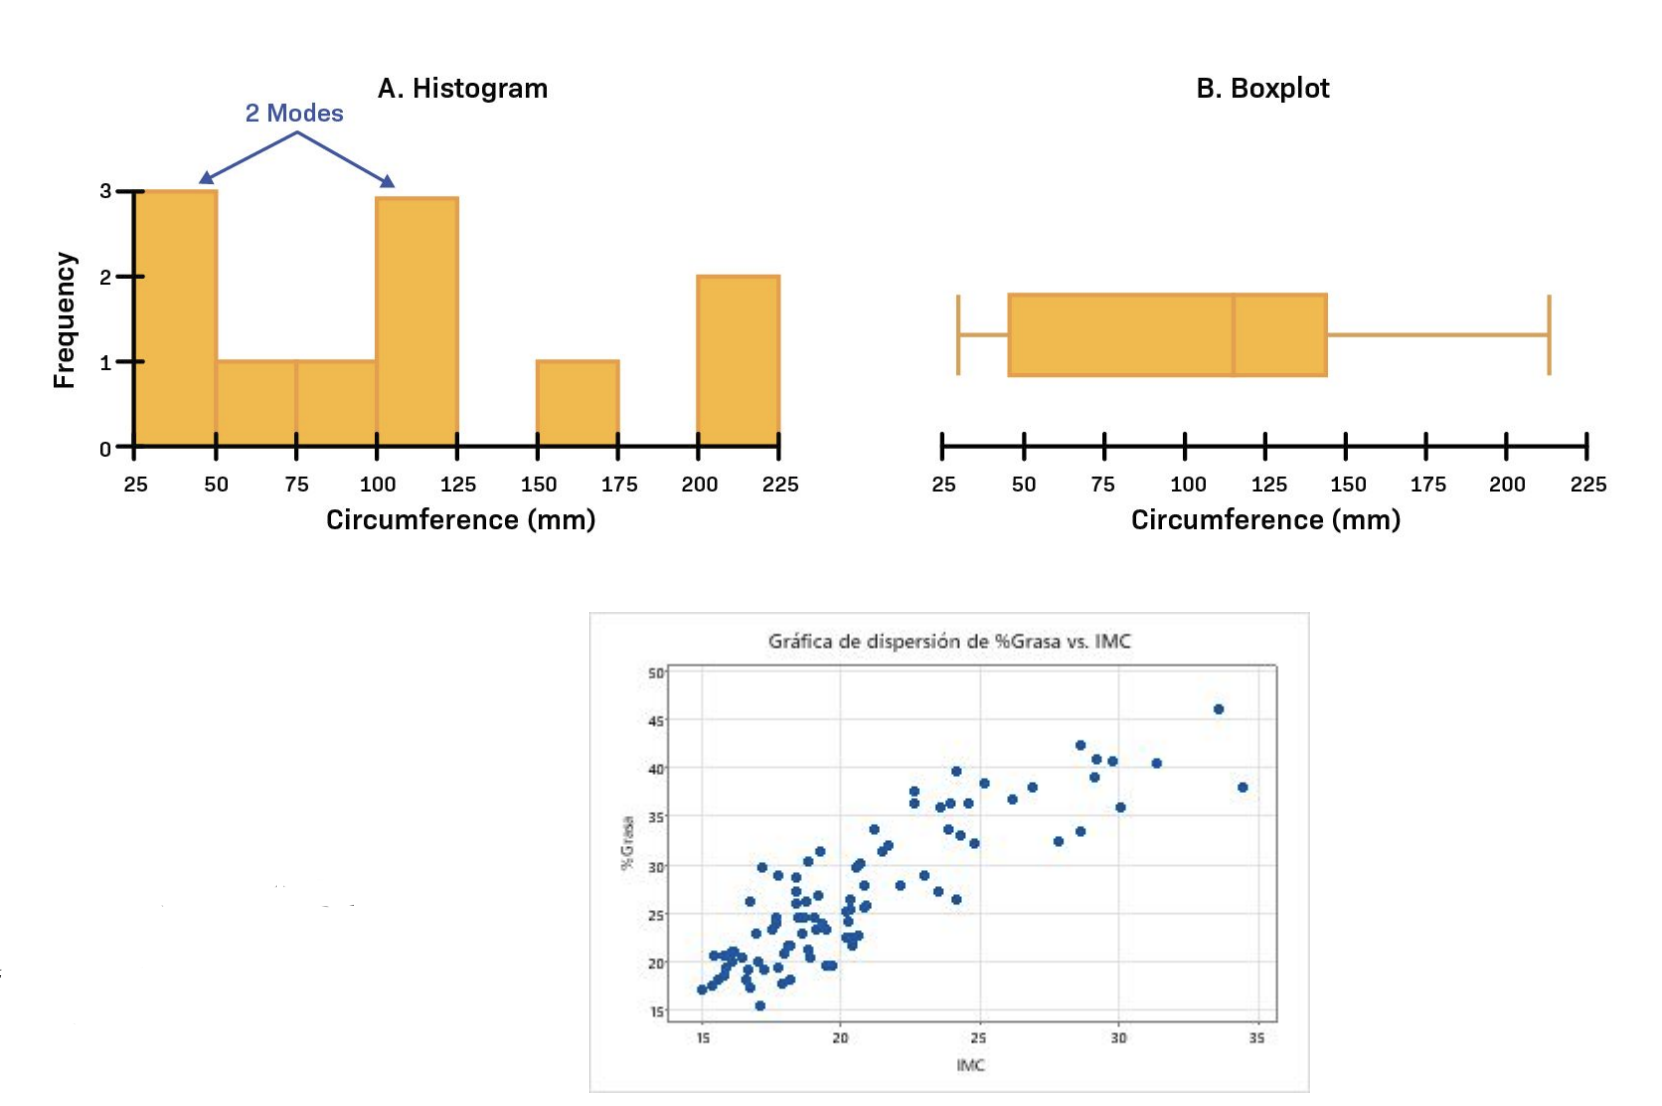